# Data Cleaning

## Handling:
- Accuracy
- Consistency
- Complenteness
- Uniqueness
- Outliers

## Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Read Data

In [8]:
df = pd.read_csv('../../data/raw/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Accuracy
1. Invalid Gender Values - 18 others
2. Infant Smokers

In [9]:
df = df[~(df['gender'] == 'Other')]
df[df['gender'] == 'Other']

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [10]:
df[(df['age'] < 10) & (df['diabetes'] == 1)]['smoking_history'].value_counts()

smoking_history
No Info        10
never          10
ever            1
not current     1
Name: count, dtype: int64

In [11]:
df[(df['age'] < 10)]['smoking_history'].value_counts()

smoking_history
No Info        8391
never          1156
not current     189
current          20
ever              4
former            1
Name: count, dtype: int64

In [12]:
df = df[~((df['age'] < 10) & (df['smoking_history'].isin(['not current', 'current', 'ever', 'former'])))]
df[(df['age'] < 10)]['smoking_history'].value_counts()

smoking_history
No Info    8391
never      1156
Name: count, dtype: int64

## Uniqueness

- Duplicate Records: `3854 `

In [13]:
exact_duplicates = df.duplicated().sum()
unique_duplicates = df[df.duplicated()].drop_duplicates().shape[0]

print(f'exact_duplicates: {exact_duplicates}')
print(f'unique_exact_duplicates: {unique_duplicates}')

df[df.duplicated()].head()


exact_duplicates: 3854
unique_exact_duplicates: 3085


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
2756,Male,80.0,0,0,No Info,27.32,6.6,159,0
3272,Female,80.0,0,0,No Info,27.32,3.5,80,0
3418,Female,19.0,0,0,No Info,27.32,6.5,100,0
3939,Female,78.0,1,0,former,27.32,3.5,130,0
3960,Male,47.0,0,0,No Info,27.32,6.0,200,0


#### Duplicates with diabetes

In [14]:
duplicates_having_diabetes = df[df.duplicated() & df['diabetes'] == 1]
unique_duplicates_having_diabetes = df[df.duplicated() & df['diabetes'] == 1].drop_duplicates()

print(f'duplicates_having_diabetes: {len(duplicates_having_diabetes)}')
print(f'unique_duplicates_having_diabetes: {len(unique_duplicates_having_diabetes)}')

df[df.duplicated() & df['diabetes'] == 1]

duplicates_having_diabetes: 18
unique_duplicates_having_diabetes: 17


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
25295,Male,38.0,0,0,No Info,31.85,5.7,220,1
31605,Female,53.0,0,0,never,27.32,6.6,155,1
39559,Male,66.0,0,0,No Info,27.32,5.7,130,1
41910,Female,80.0,1,0,No Info,27.32,7.5,160,1
55391,Female,80.0,0,0,No Info,27.32,8.8,240,1
61379,Female,80.0,0,0,never,27.32,7.0,130,1
72887,Female,76.0,0,0,No Info,27.32,6.2,260,1
72978,Female,80.0,0,0,No Info,27.32,6.5,240,1
77327,Female,77.0,1,0,No Info,27.32,6.5,220,1
84394,Female,80.0,0,0,never,27.32,8.2,280,1


#### Remove duplicates

In [15]:
df = df.drop_duplicates(keep='first')
print(df.duplicated().sum())

0


## Completeness

- Check whether to handle the no info category or keep it

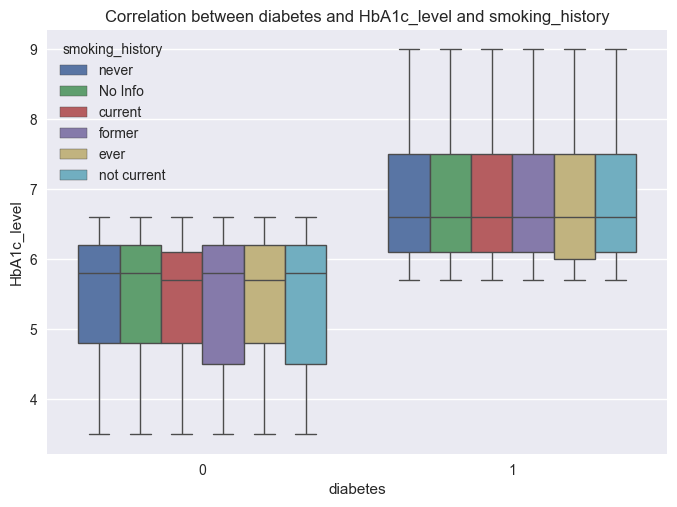

In [16]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level", hue='smoking_history') 
plt.title("Correlation between diabetes and HbA1c_level and smoking_history")
plt.xlabel("diabetes")
plt.ylabel("HbA1c_level")
plt.show()

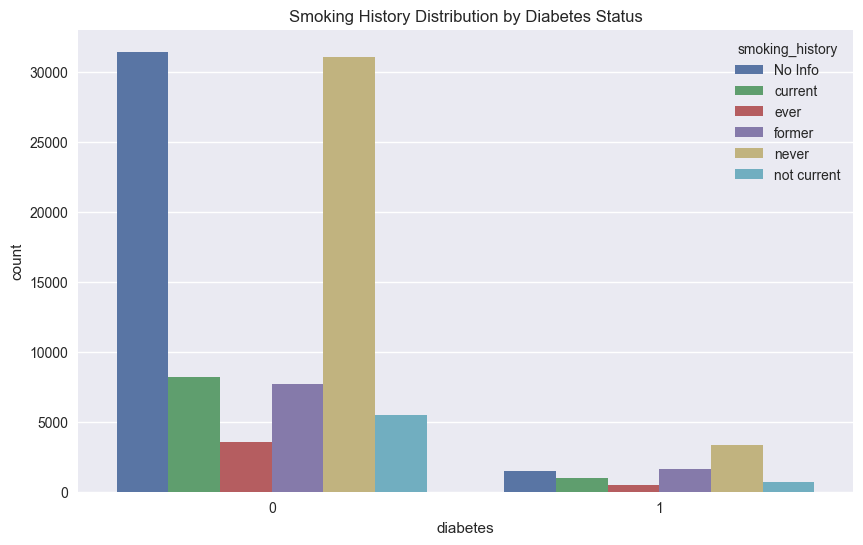

In [17]:
counts = df.groupby(["diabetes", "smoking_history"]).size().reset_index(name="count")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=counts,
    x="diabetes",
    y="count",
    hue="smoking_history"
)

plt.title("Smoking History Distribution by Diabetes Status")
plt.xlabel("diabetes")
plt.ylabel("count")
plt.show()

In [18]:
df.groupby("smoking_history")["diabetes"].mean().sort_values()

smoking_history
No Info        0.043946
never          0.097020
current        0.103302
not current    0.111669
ever           0.117956
former         0.171005
Name: diabetes, dtype: float64

- As it looks, the data no info carry information and it is better not to be removed or replaced

## Outliers

Check whether to handle the outliers or not if they have important information

- BMI
- HbA1c_level
- blood_glucose_level

### BMI

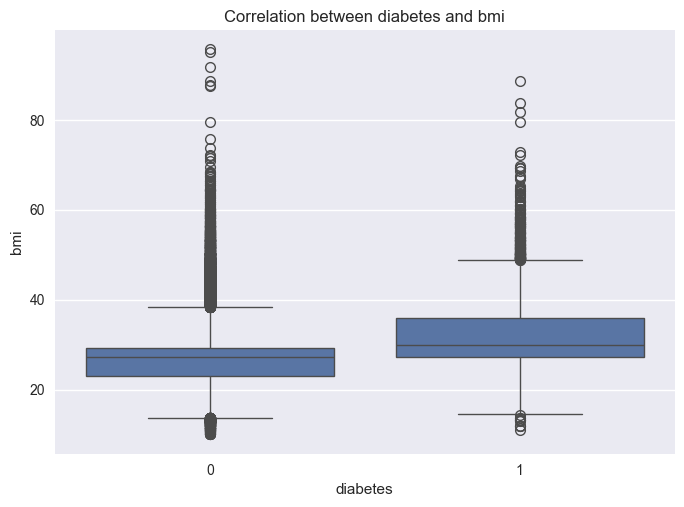

In [19]:
sns.boxplot(data=df, x="diabetes", y="bmi") 
plt.title("Correlation between diabetes and bmi")
plt.xlabel("diabetes")
plt.ylabel("bmi")
plt.show()

### HbA1c_level

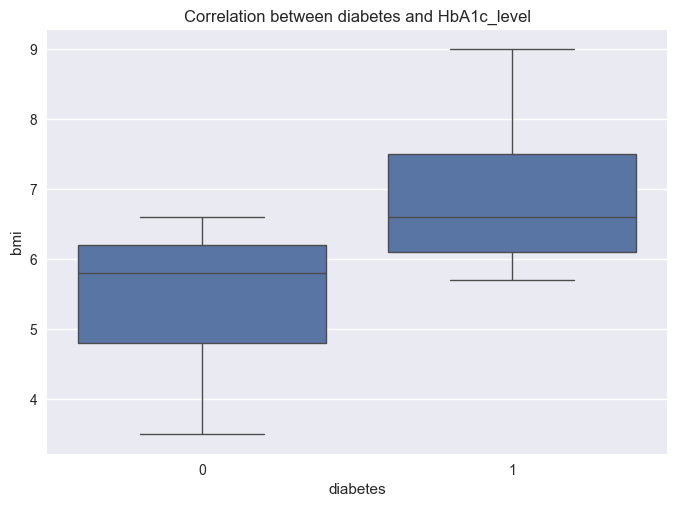

In [20]:
sns.boxplot(data=df, x="diabetes", y="HbA1c_level") 
plt.title("Correlation between diabetes and HbA1c_level")
plt.xlabel("diabetes")
plt.ylabel("bmi")
plt.show()

In [31]:
df[(df['HbA1c_level'] > 6.6) & (df['diabetes'] != 1)]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


### blood_glucose_level

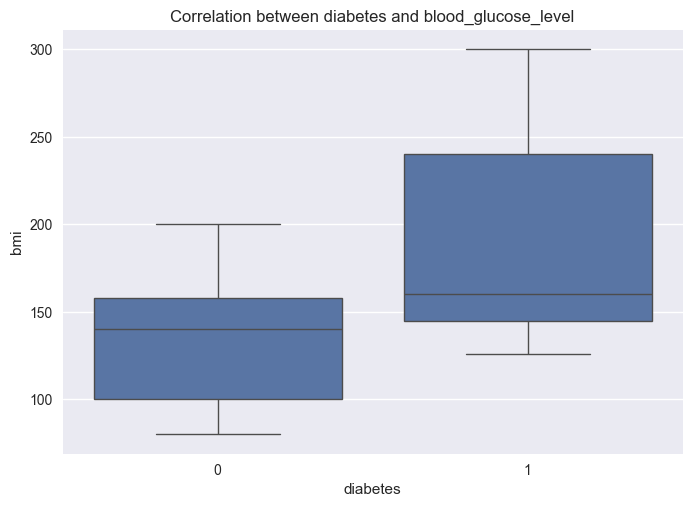

In [22]:
sns.boxplot(data=df, x="diabetes", y="blood_glucose_level") 
plt.title("Correlation between diabetes and blood_glucose_level")
plt.xlabel("diabetes")
plt.ylabel("bmi")
plt.show()

In [23]:
df[(df['blood_glucose_level'] > 200) & (df['diabetes'] != 1)]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


It seems like the outliers carry important info., so it is better not to remove them

## Export Cleaned Data

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 95914 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               95914 non-null  str    
 1   age                  95914 non-null  float64
 2   hypertension         95914 non-null  int64  
 3   heart_disease        95914 non-null  int64  
 4   smoking_history      95914 non-null  str    
 5   bmi                  95914 non-null  float64
 6   HbA1c_level          95914 non-null  float64
 7   blood_glucose_level  95914 non-null  int64  
 8   diabetes             95914 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 7.3 MB


In [25]:
df['gender'].value_counts()

gender
Female    56062
Male      39852
Name: count, dtype: int64

In [26]:
df['hypertension'].value_counts()

hypertension
0    88454
1     7460
Name: count, dtype: int64

In [27]:
df['heart_disease'].value_counts()

heart_disease
0    91993
1     3921
Name: count, dtype: int64

In [28]:
df['smoking_history'].value_counts()

smoking_history
never          34395
No Info        32881
former          9298
current         9177
not current     6170
ever            3993
Name: count, dtype: int64

In [29]:
df['diabetes'].value_counts()

diabetes
0    87434
1     8480
Name: count, dtype: int64

#### Saving to cleaned_1.csv

In [30]:
df.to_csv('../../data/cleaned/cleaned_1.csv', index=False)